<h1>Phishing website evaluation using decision trees and random forests</h1>

<h2>1. Business understanding</h2>

The pipeline uses data from https://archive.ics.uci.edu/dataset/327/phishing+websites. The dataset contains a set of URLs that have been evaluated using a list of features that have been proved effective in predicting whether or not the URL leads to **1 = legitimate** or **-1 = phishing** website.

Our goal is to create a pipeline that uses decision trees and random forests to reliably predict whether or not any given website leads to a legitimate or phishing website based on the easily obtainable information about the website. If successful, it could be used to create automated system to warn users of dangerous websites.

<h2>2. Data understanding</h2>

In [7]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import matplotlib.pyplot as plt

# fetch dataset 
df = fetch_ucirepo(id=327) 

# data (as pandas dataframes) 
X = df.data.features  # input features
y = df.data.targets # target features

In [8]:
# metadata 
print(json.dumps(df.metadata, indent=2))

{
  "uci_id": 327,
  "name": "Phishing Websites",
  "repository_url": "https://archive.ics.uci.edu/dataset/327/phishing+websites",
  "data_url": "https://archive.ics.uci.edu/static/public/327/data.csv",
  "abstract": "This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Google\u00e2\u20ac\u2122s searching operators.",
  "area": "Computer Science",
  "tasks": [
    "Classification"
  ],
  "characteristics": [
    "Tabular"
  ],
  "num_instances": 11055,
  "num_features": 30,
  "feature_types": [
    "Integer"
  ],
  "demographics": [],
  "target_col": [
    "result"
  ],
  "index_col": null,
  "has_missing_values": "no",
  "missing_values_symbol": null,
  "year_of_dataset_creation": 2012,
  "last_updated": "Tue Mar 05 2024",
  "dataset_doi": "10.24432/C51W2X",
  "creators": [
    "Rami Mohammad",
    "Lee McCluskey"
  ],
  "intro_paper": {
    "ID": 396,
    "type": "NATIVE",
    "title": "An assessment of features related to phishing websites using an automated 

Metadata above contains indepth information about the dataset, its creators, date and original links to its publication.

In [10]:
# variable information 
print(df.variables) 

                          name     role     type demographic description  \
0            having_ip_address  Feature  Integer        None        None   
1                   url_length  Feature  Integer        None        None   
2           shortining_service  Feature  Integer        None        None   
3             having_at_symbol  Feature  Integer        None        None   
4     double_slash_redirecting  Feature  Integer        None        None   
5                prefix_suffix  Feature  Integer        None        None   
6            having_sub_domain  Feature  Integer        None        None   
7               sslfinal_state  Feature  Integer        None        None   
8   domain_registration_length  Feature  Integer        None        None   
9                      favicon  Feature  Integer        None        None   
10                        port  Feature  Integer        None        None   
11                 https_token  Feature  Integer        None        None   
12          

Dataset does not appear to have any missing values and its types are correctly assigned.

In [12]:
X.describe(include='all')

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.913885,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.405991,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Phishing websites dataframe contains 11055 sample URLs with 30 different features, contained in the variable `X`. Each feature has a value of 1 (legitimate), 0 (suspicious) or -1 (phishing). Not every feature can have 0 as value. Results 1 (legitimate) or -1 (phishing) are contained in the variable `y`.

We can observe that the values presented do not differ in magnitude. Nor do they contain any outliers, as both mean and max are in all cases within min and max.

<h2>3. Data preparation</h2>

To prepare the data for modeling, we must first split it to training data and testing data. As we had already observed, in absense of differences in magnitude, scaling of values is not necessary.

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8291, 30) (2764, 30) (8291, 1) (2764, 1)


<h2>4. Modeling</h2>

 - Valitaan koneoppimismenetelmä, opetetaan malli ja validoidaan se (validation).
 - Dokumentointiin on sisällytettävä tarkasti valittu menetelmä, käytetyt parametrit sekä mitattu mallin suorituskyky.
 - Millä perusteella tehty valinnat
 - Taulukko on hyvä viestimiseen
 - Ei tarvitse olla yksityiskohtainen, mutta selitetään miksi on päädytty lopputulokseen.

We have chosen **decision tree** from **Scikit-learn Python library** as our machine learning method to train the model.

An instance of `DecisionTreeClassifier` class is created and the model is trained using its `fit` method. Parameters `max_depth` is notable for restricting the size of the tree.

In [158]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(max_depth=3, random_state=20)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=20)

Using the constructed classifier, the tree can now be visualized. Changing the earlier `max_depth` can dramatically alter the complexity of visualization, in which case altering `figsize` is often necessary for readability.

Names of classes must be given as parameters.

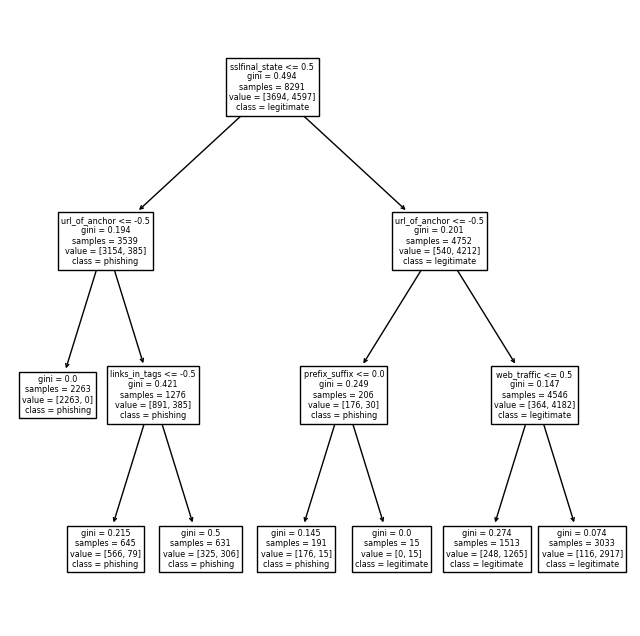

In [161]:
fig = plt.figure(figsize = (8, 8))
plot_tree(
    model, 
    feature_names = list(X.keys()), 
    class_names = ['phishing', 'legitimate'])
plt.show()

We can test the performance of our classifier by giving it previously unseen data. `Predict` method determines the sample classes, which are then compared with the true labels. Results are presented with `confusion_matrix`.

<h3>Validation</h2>

In [137]:
from sklearn.metrics import confusion_matrix, classification_report

preds = model.predict(X_test)

confusion_matrix(y_test, preds)

array([[1095,  109],
       [ 148, 1412]], dtype=int64)

In [145]:
print( classification_report(y_test, preds) )

              precision    recall  f1-score   support

          -1       0.88      0.91      0.89      1204
           1       0.93      0.91      0.92      1560

    accuracy                           0.91      2764
   macro avg       0.90      0.91      0.91      2764
weighted avg       0.91      0.91      0.91      2764



<b>Confusion matrix</b> <br/>
Test data amount is 2764 samples ($1095 + 109 + 148 + 1412$). The model predicts 2507 time correct which is approximately 91% accuracy. There was 257 incorrect predictions and these incorrect predictions are divided evenly in false negatives and false positives which indicates that it does not favor one or another.

<b>Classification report</b> <br/>
With given metrics from <i>confusion matrix</i> and <i>classification report</i> we can be sure that our model is stable and works approximately 9 times out of 10. Classification report supports the conclusion from the <i>confusion matrix</i>, the model predicts legitimate websites with slightly better precision, but there is no big gap between these two. We can see that these metrics indeed can be trusted by the amount of samples in each category. (1204 phishing sites and 1560 legimate sites)

<h2>5. Evaluation</h2>

<b>Decision tree</b><br/>
The developed pipeline with decision tree model detects phishing websites with high accuracy and serves as a reliable tool for classification. The model predicts correctly approximately 90% of the time whether a given website is legitimate. <br/>

While the model provides significant value and helps users browse the internet more safely, it does not achieve 100% accuracy. Therefore, when utilizing this pipeline in everyday applications or business environments, users must still exercise caution. <br/>

The potential damage caused by online scams can be severe, potentially costing users or businesses large financial losses, stolen user data, compromised bank accounts, and subsequent reputational damage or even bankruptcy. Because the stakes are high, the model should not be relied upon blindly, but instead, combined with security-aware users, it can serve as a powerful tool in maintaining digital safety.

<h2>6. Deployment</h2>

This model could be integrated to end-users as light addon in browser or as a tool in business network security filter. System would analyze incoming URL traffic in real-time.

Because model makes mistakes, the system should not blindly trust its capabilities, but instead give a clear warning about phishing site suspicions.

Because websites and URLs change, the system should have maybe a feedback system or data collection within. This way the model can stay up to date and retrained with new findings.